In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [4]:
df = pd.read_json(r"C:\Users\Admin\Downloads\prescription_raw_text_only.json")

In [5]:
print(df.head())

                                            raw_text
0               Fexofenadin 120 mg OD allergy 7 days
1  Tab. Amitriptyline 25 mg 1 tablet OD for 5 day...
2  Tab Ranitidine 150 mg 1 tablet BD 10 Days at b...
3  Cap Loperamide 2 mg 1 capsule SOS 14 days for ...
4  Tab Vitamin D3 1000 IU 1 tablet OD x 3 days af...


In [6]:
FORM_MAP = { 
    "tab": "tablet",
    "cap": "capsule",
    "syp": "syrup",
    "inj": "injection"
}
FREQ_LIST = ["od","bd","tds","qid","hs","sos"]

In [9]:
def extract_fields(text):
    text_lower = text.lower()

    medicine_name = ""
    form = ""
    strength = ""
    dosage = ""
    frequency = ""
    duration = ""
    notes = ""

    words = text_lower.split()

     for i, word in enumerate(words):
        if word in FORM_MAP:
            form = FORM_MAP[word]
            if i + 1 < len(words):
                medicine_name = words[i + 1].capitalize()

IndentationError: unexpected indent (3006815923.py, line 14)

In [8]:
 for i, word in enumerate(words):
        if word in FORM_MAP:
            form = FORM_MAP[word]
            if i + 1 < len(words):
                medicine_name = words[i + 1].capitalize()

NameError: name 'words' is not defined

In [11]:
def extract_fields(text):
    text_lower = text.lower()

    medicine_name = ""
    form = ""
    strength = ""
    dosage = ""
    frequency = ""
    duration = ""
    notes = ""

    words = text_lower.split()

    # Medical
    for i, word in enumerate(words):
        if word in FORM_MAP:
            form = FORM_MAP[word]
            if i + 1 < len(words):
                medicine_name = words[i + 1].capitalize()

    # Sterngth
    strength_match = re.search(r'\d+\s*mg', text_lower)
    if strength_match:
        strength = strength_match.group()

    # dosage
    dosage_match = re.search(r'\d+\s*(tablet|capsule|ml)', text_lower)
    if dosage_match:
        dosage = dosage_match.group()

    # frequency
    for freq in FREQ_LIST:
        if freq in text_lower:
            frequency = freq.upper()

    #duration
    duration_match = re.search(r'\d+\s*days?', text_lower)
    if duration_match:
        duration = duration_match.group()

     # NOTES 
    temp = text_lower
    for val in [medicine_name, form, strength, dosage, frequency.lower(), duration]:
        if val:
            temp = temp.replace(val.lower(), "")

    notes = temp.strip()

    return pd.Series([
        medicine_name, form, strength,
        dosage, frequency, duration, notes
    ])

In [12]:
df[['medicine_name','form','strength','dosage','frequency','duration','notes']] = \
    df['raw_text'].apply(extract_fields)

In [13]:
# missing values
df.fillna("Unknown", inplace=True)

In [14]:
# Add flag col
df['has_strength'] = np.where(df['strength'] != "", 1, 0)

In [15]:
# Convert duration to numeric
df['duration_days'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [16]:
# to save outputt
df.to_json("structured_output.json", orient="records", indent=4)

In [17]:
df.shape

(10000, 10)

In [18]:
df.head()

,raw_text,medicine_name,form,strength,dosage,frequency,duration,notes,has_strength,duration_days
0,Fexofenadin 120 mg OD allergy 7 days,,,120 mg,,OD,7 days,fexofenadin allergy,1,7.0
1,Tab. Amitriptyline 25 mg 1 tablet OD for 5 day...,,,25 mg,1 tablet,OD,5 days,tab. amitriptyline for at bedtime,1,5.0
2,Tab Ranitidine 150 mg 1 tablet BD 10 Days at b...,Ranitidine,tablet,150 mg,1 tablet,BD,10 days,tab 1 at bedtime,1,10.0
3,Cap Loperamide 2 mg 1 capsule SOS 14 days for ...,Loperamide,capsule,2 mg,1 capsule,SOS,14 days,cap 1 for diarrhoea,1,14.0
4,Tab Vitamin D3 1000 IU 1 tablet OD x 3 days af...,Vitamin,tablet,,1 tablet,OD,3 days,tab d3 1000 iu 1 x after fo,0,3.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raw_text       10000 non-null  object 
 1   medicine_name  10000 non-null  object 
 2   form           10000 non-null  object 
 3   strength       10000 non-null  object 
 4   dosage         10000 non-null  object 
 5   frequency      10000 non-null  object 
 6   duration       10000 non-null  object 
 7   notes          10000 non-null  object 
 8   has_strength   10000 non-null  int64  
 9   duration_days  3590 non-null   float64
dtypes: float64(1), int64(1), object(8)
memory usage: 781.4+ KB


In [20]:
pd.isnull(df)

,raw_text,medicine_name,form,strength,dosage,frequency,duration,notes,has_strength,duration_days
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,True
9997,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,True


In [21]:
pd.isnull(df).sum()

raw_text            0
medicine_name       0
form                0
strength            0
dosage              0
frequency           0
duration            0
notes               0
has_strength        0
duration_days    6410
dtype: int64

In [22]:
df.dropna(inplace= True)

In [23]:
pd.isnull(df).sum()

raw_text         0
medicine_name    0
form             0
strength         0
dosage           0
frequency        0
duration         0
notes            0
has_strength     0
duration_days    0
dtype: int64

In [24]:
df.shape

(3590, 10)

In [25]:
print(df['frequency'].value_counts())

frequency
OD     1377
BD      799
        574
TDS     343
HS      291
SOS     178
QID      28
Name: count, dtype: int64


In [27]:
print(df['form'].value_counts())

form
             2425
tablet        876
capsule       188
injection     101
Name: count, dtype: int64


In [28]:
df.describe()

,has_strength,duration_days
count,3590.000000,3590.000000
mean,0.940390,6.752089
std,0.236796,3.495783
min,0.000000,3.000000
25%,1.000000,3.000000
50%,1.000000,5.000000
75%,1.000000,10.000000
max,1.000000,17.000000


In [29]:
df.columns

Index(['raw_text', 'medicine_name', 'form', 'strength', 'dosage', 'frequency',
       'duration', 'notes', 'has_strength', 'duration_days'],
      dtype='object')

<Axes: xlabel='frequency'>

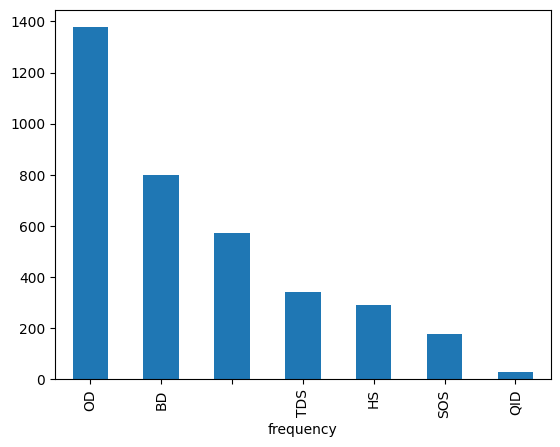

In [30]:
plt.figure()
df['frequency'].value_counts().plot(kind='bar')

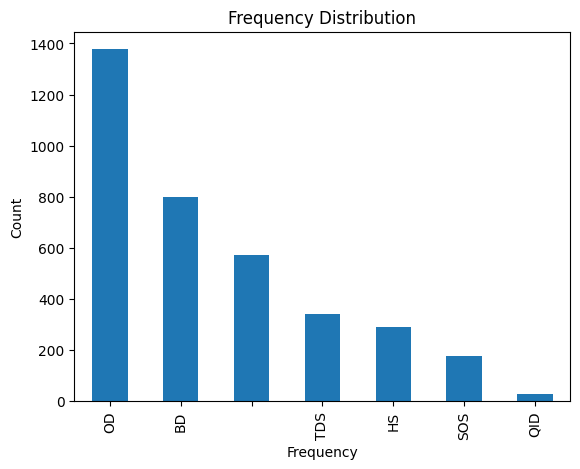

In [31]:
plt.figure()
df['frequency'].value_counts().plot(kind='bar')
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='form'>

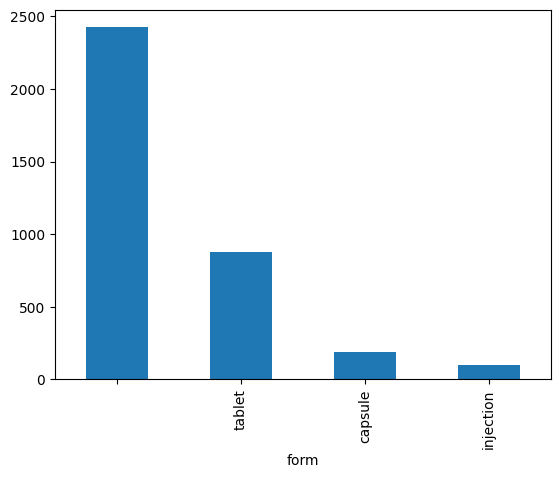

In [32]:
plt.figure()
df['form'].value_counts().plot(kind='bar')

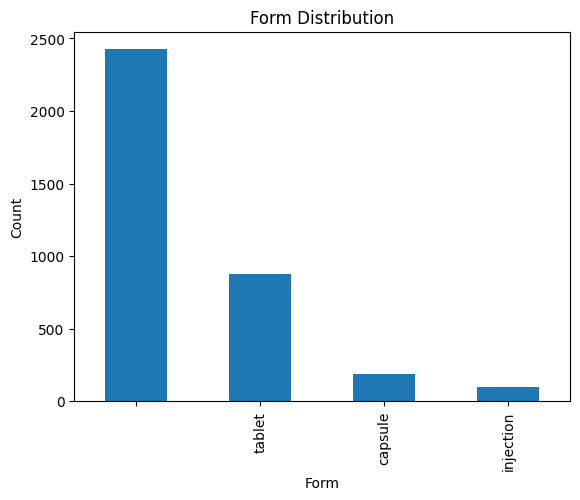

In [33]:
plt.figure()
df['form'].value_counts().plot(kind='bar')
plt.title("Form Distribution")
plt.xlabel("Form")
plt.ylabel("Count")
plt.show()